# งานที่สาม : การเลือกดีกรีของพหุนาม และพฤติกรรม overfitting ด้วยการจำลอง (simulation)

**ฟังก์ชันเป้าหมายจริง** : $f(x) = \sin(\pi x)$  
**ข้อมูล** : สุ่ม $x$ จำนวน $n$ จุด จาก $U[-1, 1]$ แล้วบวก noise $\sim N(0, \sigma^2)$ &nbsp;$\Rightarrow\; y = f(x) + \text{noise}$  
**แบบจำลอง** : พหุนามดีกรี $d$ &nbsp;($d = 0, 1, \dots, D$) &nbsp;— $d=0$ ค่าคงที่, $d=1$ เชิงเส้น, ดีกรีสูงขึ้น = ยืดหยุ่นขึ้น

**ประเมิน error 2 แบบ**
1. **resubstitution ($E_{in}$)** — ฟิตบนข้อมูลทั้ง $n$ จุด แล้ววัด error บน $n$ จุดเดิม
2. **k-fold cross-validation ($E_{cv}$)** — แบ่งเป็น $k$ ก้อน วนให้แต่ละก้อนเป็น test แล้วเฉลี่ย error

**สิ่งที่ต้องหา**
- **(a)** ข้อมูล 1 ชุด : หา $E_{in}$ และ $E_{cv}$ ของทุกดีกรี วาดเทียบดีกรี เทียบกับ $E_{out}$ จริง สังเกตว่าดีกรีใดให้ CV ต่ำสุด
- **(b)** ทำซ้ำหลายชุด : ค่ากลางของ $E_{in}, E_{cv}, E_{out}$ จริง รายดีกรี แล้วเทียบว่าการเลือกดีกรีด้วย training error กับด้วย CV ต่างกันอย่างไร และ CV ใกล้ $E_{out}$ แค่ไหน
- **(c)** ปรับ $n$ และ $\sigma$ : ดูผลต่อดีกรีที่ดีที่สุด และความรุนแรงของ overfitting
- **(d)** ขนาดสัมประสิทธิ์สูงสุด $|w|$ เทียบดีกรี : อธิบายความเชื่อมโยงกับการเกิด overfitting

## 0) แนวคิดสำคัญที่ใช้

* **$E_{in}$ (training error, resubstitution)** : วัด error บนข้อมูลชุดเดียวกับที่ใช้เทรน → "มองโลกในแง่ดี" ยิ่งดีกรีสูง $E_{in}$ ยิ่งลดลงเรื่อย ๆ จน $\approx 0$ ที่ดีกรีสูงมาก ⇒ ใช้เลือกดีกรีไม่ได้ เพราะจะเชียร์ดีกรีสูงสุดเสมอ (overfit)
* **$E_{cv}$ (k-fold CV error)** : วัด error บนก้อนที่ "ไม่ได้ใช้เทรน" → เป็นตัวแทนของ error บนข้อมูลใหม่ กราฟมักเป็น **รูปตัว U** : ต่ำเกิน = underfit, สูงเกิน = overfit จุดต่ำสุด = ดีกรีที่เหมาะสม
* **$E_{out}$ จริง** (มีเฉพาะในการจำลองเพราะรู้ $f$ จริง) : $E_{out}(g) = \mathbb{E}_x[(g(x)-f(x))^2] + \sigma^2$ — พจน์แรกประมาณด้วยกริดถี่ 1001 จุด, พจน์ $\sigma^2$ คือ noise ที่ลดไม่ได้ ใช้เป็น "เฉลย"
* **ค่ากลางจากการทำซ้ำ $M$ ชุด (Monte-Carlo)** : ข้อมูล 1 ชุดมีความบังเอิญสูง จึงทำซ้ำหลายชุดแล้วเฉลี่ยเพื่อดูแนวโน้มจริง

## 1) โมดูลแบบจำลอง (เดิมคือ `models.py`)

generalize จาก constant/linear ของงานก่อน มาเป็นพหุนามทุกดีกรีในฟังก์ชันเดียว
- `TARGET = sin(pi*x)`
- `fit_poly(x, y, d)` = `np.polyfit` ดีกรี $d$ (least squares คืนสัมประสิทธิ์ดีกรีสูงก่อน)
- `predict(coef, x)` = `np.polyval` (รองรับทุกดีกรีในสูตรเดียว)
- ปิด `RankWarning` ของ polyfit (ดีกรีสูง+จุดน้อย) เพราะเป็นอาการ overfit ที่ตั้งใจให้เห็น

In [1]:
# -*- coding: utf-8 -*-
import warnings                                # ใช้ปิด warning ของ polyfit ที่ดีกรีสูง/จุดน้อย
import numpy as np                             # numpy สำหรับงานคำนวณเวกเตอร์/เมทริกซ์
import matplotlib.pyplot as plt                # ไลบรารีวาดกราฟ

# ดีกรีสูง + จุดน้อย ทำให้เมทริกซ์ near-singular -> polyfit เตือน RankWarning
# ปิดไว้เพราะ "อาการนั้นคือ overfitting ที่ตั้งใจให้เห็น" ไม่ใช่ข้อผิดพลาดของโค้ด
# (numpy 2.x ย้าย RankWarning ไป np.exceptions -> รองรับทั้งเก่า/ใหม่)
_RankWarning = getattr(np, "RankWarning", getattr(np.exceptions, "RankWarning", Warning))
warnings.simplefilter("ignore", _RankWarning)

# ฟังก์ชันเป้าหมายจริงของงานนี้: คลื่นไซน์ sin(pi*x) (โจทย์กำหนดมาแบบเดียว)
TARGET = lambda x: np.sin(np.pi * x)


def fit_poly(x, y, d):                         # ฟิตพหุนามดีกรี d บนข้อมูล (x, y)
    # np.polyfit = least squares หาสัมประสิทธิ์ที่ MSE ต่ำสุด, คืน [w_d, ..., w_1, w_0]
    # (สัมประสิทธิ์ดีกรีสูงสุดมาก่อน) -> d=0 จะได้ค่าคงที่ = ค่าเฉลี่ยของ y
    return np.polyfit(x, y, d)


def predict(coef, x):                          # ทำนายค่า y จากสัมประสิทธิ์พหุนาม coef
    return np.polyval(coef, x)                 # ประเมินพหุนาม รองรับทุกดีกรีในสูตรเดียว

## 2) ค่าคงที่รวม และฟังก์ชันย่อยหลัก (เดิมอยู่บนสุดของ `poly_degree.py`)

ค่าคงที่รวมบนสุด (สไตล์ C: ตัวแปรที่ใช้ซ้ำ/ใช้เยอะอยู่ที่เดียว) — แก้ตรงนี้แล้วรันเซลล์ถัดไปได้ทันที

In [2]:
# ---------- ค่าคงที่รวม ----------
SEED = 42                                          # seed ตัวสุ่ม (ผลซ้ำได้ทุกครั้ง)
N = 15                                             # จำนวนตัวอย่าง n เริ่มต้น
SIGMA = 0.3                                        # ค่าเบี่ยงเบนมาตรฐานของ noise เริ่มต้น
MAXDEG = 10                                        # ดีกรีสูงสุด D (จะกวาด d = 0..D)
K_FOLD = 5                                         # จำนวน fold ของ cross-validation
M_DATASETS = 300                                   # จำนวนชุดข้อมูลที่ทำซ้ำ (Monte Carlo)
GRID = np.linspace(-1, 1, 1001)                    # กริด x ถี่ ๆ ไว้คำนวณ E_out จริง

In [3]:
# ======================= ฟังก์ชันย่อยหลัก (ใช้ซ้ำทุกหัวข้อ) =======================

def make_data(n, sigma, rng):
    """สุ่มชุดข้อมูล 1 ชุด: x ~ U[-1,1] จำนวน n จุด, y = f(x) + noise"""
    x = rng.uniform(-1, 1, n)                      # สุ่ม x จากการแจกแจงเอกรูปในช่วง [-1,1]
    y = TARGET(x) + sigma * rng.standard_normal(n) # ค่าจริง sin(pi*x) บวก noise แบบปรกติ
    return x, y


def mse(coef, x, y):
    """error กำลังสองเฉลี่ยของพหุนาม coef บนจุด (x, y)"""
    return np.mean((predict(coef, x) - y) ** 2)


def true_eout(coef, sigma):
    """E_out จริงของพหุนามที่ฟิตแล้ว = ค่าคาดหวัง error บนจุดทดสอบใหม่ (มี noise)
       = E_x[(g(x)-f(x))^2] (ประมาณด้วยกริดถี่) + sigma^2 (noise floor ที่ลดไม่ได้)"""
    return np.mean((predict(coef, GRID) - TARGET(GRID)) ** 2) + sigma ** 2


def est_resub(x, y, d):
    """resubstitution (E_in): ฟิตดีกรี d บนข้อมูลทั้งหมด แล้ววัด error บนจุดเดิม"""
    return mse(fit_poly(x, y, d), x, y)            # error บนชุดเดิม (มักต่ำกว่า E_out จริง)


def est_kfold(x, y, d, k, rng):
    """k-fold CV (E_cv): สับข้อมูลแล้วแบ่งเป็น k ก้อน วนให้แต่ละก้อนเป็น test ทีละครั้ง
       ฟิตดีกรี d บนก้อนที่เหลือ วัด error บนก้อนที่กันไว้ แล้วเฉลี่ยทุกก้อน"""
    folds = np.array_split(rng.permutation(len(x)), k)   # สับดัชนีแล้วแบ่งเป็น k ก้อน
    errs = []                                      # เก็บ error ของแต่ละ fold ไว้เฉลี่ย
    for i in range(k):                             # วนเลือก fold ที่ i เป็น test
        test = folds[i]                            # ก้อนที่ i = ชุดทดสอบ
        train = np.concatenate([folds[j] for j in range(k) if j != i])  # ก้อนที่เหลือ = ชุดฝึก
        errs.append(mse(fit_poly(x[train], y[train], d), x[test], y[test]))  # error บน fold ทดสอบ
    return np.mean(errs)                           # เฉลี่ย error เหนือทุก fold


def errors_by_degree(x, y, sigma, k, rng, D):
    """สำหรับข้อมูล 'ชุดเดียว': วน d = 0..D คืน 3 อาเรย์ (E_in, E_cv, E_out จริง) รายดีกรี"""
    e_in, e_cv, e_out = [], [], []                 # ลิสต์สะสมค่าของแต่ละดีกรี
    for d in range(D + 1):                         # วนทุกดีกรีตั้งแต่ 0 ถึง D
        e_in.append(est_resub(x, y, d))            # training error (resubstitution)
        e_cv.append(est_kfold(x, y, d, k, rng))    # cross-validation error
        e_out.append(true_eout(fit_poly(x, y, d), sigma))  # E_out จริงของโมเดลเต็มชุด
    return map(np.array, (e_in, e_cv, e_out))      # แปลงเป็น numpy array ทั้ง 3 ตัว

## (a) ข้อมูล 1 ชุด

หา $E_{in}$ และ $E_{cv}$ ของทุกดีกรี วาดเทียบดีกรี + เทียบ $E_{out}$ จริง และหาว่าดีกรีใดให้ CV ต่ำสุด

=== (a) error รายดีกรีบนข้อมูล 1 ชุด (n=15, sigma=0.30, D=10) ===
  d |      E_in      E_cv E_out(จริง)
----------------------------------------
  0 |    0.5120    0.5330      0.6639
  1 |    0.2138    0.2624      0.2904
  2 |    0.1967    0.3855      0.3157
  3 |    0.0396    0.0535      0.0959  <- CV ต่ำสุด
  4 |    0.0329    0.0711      0.1775
  5 |    0.0315    0.0903      0.1054
  6 |    0.0301 5692.9608      0.1209
  7 |    0.0295  184.9600      0.1127
  8 |    0.0283 18458.8032      1.4882
  9 |    0.0283 35007.7435      0.3001
 10 |    0.0192 49948378.9764  36480.1359
สังเกต: E_in ลดลงเรื่อย ๆ ตามดีกรี (overfit) แต่ E_cv เป็นรูปตัว U -> CV เลือก d=3


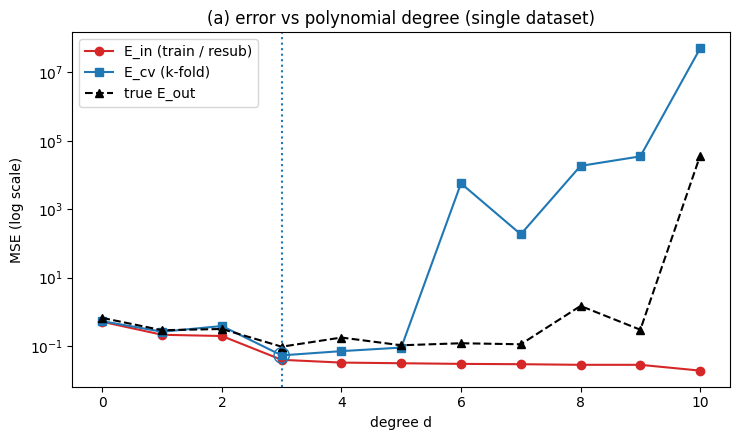

In [4]:
rng = np.random.default_rng(SEED)              # ตัวสุ่มกลาง ใช้ร่วมทุกหัวข้อ (ผลซ้ำได้)

print("=== (a) error รายดีกรีบนข้อมูล 1 ชุด (n=%d, sigma=%.2f, D=%d) ==="
      % (N, SIGMA, MAXDEG))
x, y = make_data(N, SIGMA, rng)                # สุ่มข้อมูล 1 ชุด
e_in, e_cv, e_out = errors_by_degree(x, y, SIGMA, K_FOLD, rng, MAXDEG)
best = int(np.argmin(e_cv))                    # ดีกรีที่ CV ต่ำสุด (ตัวเลือกของ CV)

print(f"{'d':>3} | {'E_in':>9} {'E_cv':>9} {'E_out(จริง)':>11}")
print("-" * 40)
for d in range(MAXDEG + 1):                    # พิมพ์ทีละดีกรี
    mark = "  <- CV ต่ำสุด" if d == best else ""
    print(f"{d:>3} | {e_in[d]:9.4f} {e_cv[d]:9.4f} {e_out[d]:11.4f}{mark}")
print(f"สังเกต: E_in ลดลงเรื่อย ๆ ตามดีกรี (overfit) แต่ E_cv เป็นรูปตัว U -> CV เลือก d={best}")

# --- วาดกราฟ error เทียบดีกรี (ป้ายอังกฤษ เพราะฟอนต์ปริยายไม่มีตัวไทย) ---
degs = np.arange(MAXDEG + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(degs, e_in, "o-", color="tab:red", label="E_in (train / resub)")
ax.plot(degs, e_cv, "s-", color="tab:blue", label="E_cv (k-fold)")
ax.plot(degs, e_out, "^--", color="k", label="true E_out")
ax.axvline(best, color="tab:blue", ls=":", lw=1.5)     # เส้นดีกรีที่ CV ต่ำสุด
ax.scatter([best], [e_cv[best]], s=120, facecolors="none", edgecolors="tab:blue", zorder=5)
ax.set_yscale("log")                           # log ช่วยเห็น E_in ที่ต่ำมากตอนดีกรีสูง
ax.set_title("(a) error vs polynomial degree (single dataset)")
ax.set_xlabel("degree d"); ax.set_ylabel("MSE (log scale)")
ax.legend()
plt.tight_layout()
plt.savefig("degree_curves.png", dpi=120)
plt.show()

## (b) ทำซ้ำหลายชุด (Monte-Carlo)

ค่ากลาง $E_{in}, E_{cv}, E_{out}$ จริง รายดีกรี → เทียบการเลือกดีกรีด้วย training error กับด้วย CV

In [5]:
def mean_errors(n, sigma, k, rng, D, M):
    """ทำซ้ำ M ชุดข้อมูล เฉลี่ย E_in, E_cv, E_out จริง รายดีกรี -> คืน 3 อาเรย์ (ยาว D+1)"""
    acc = np.zeros((3, D + 1))                     # ตัวสะสมผลรวมของ 3 ชนิด error รายดีกรี
    for _ in range(M):                             # วนทำซ้ำ M ชุด
        x, y = make_data(n, sigma, rng)            # สุ่มชุดข้อมูลใหม่
        for i, arr in enumerate(errors_by_degree(x, y, sigma, k, rng, D)):
            acc[i] += arr                          # บวกสะสมทีละชนิด (E_in/E_cv/E_out)
    return acc / M                                 # หารด้วย M -> ค่ากลาง

=== (b) ค่ากลาง error รายดีกรี (ทำซ้ำ 300 ชุด, n=15, sigma=0.30) ===
  d |      E_in      E_cv E_out(จริง)
----------------------------------------
  0 |    0.5507    0.6358      0.6250
  1 |    0.2509    0.3598      0.3277
  2 |    0.2116    0.6000      0.4742
  3 |    0.0690    0.2526      0.1692
  4 |    0.0616    1.8575      0.3059
  5 |    0.0545   12.8621      3.4492
  6 |    0.0488  280.5169     25.6938
  7 |    0.0426 94448.8831    470.8404
  8 |    0.0367 4998635.6921  10400.2105
  9 |    0.0315 95006720.7040 2555835.2963
 10 |    0.0253 49753432583309.1719 106462712.3227

เลือกดีกรีด้วย training error -> d=10  (มัก = D เพราะ E_in ลดลงตามดีกรีเสมอ = overfit)
เลือกดีกรีด้วย CV            -> d=3   เทียบดีกรีดีที่สุดจริง (E_out ต่ำสุด) -> d=3
|E_cv - E_out| เฉลี่ยทุกดีกรี = 4523038513996.5293  (ยิ่งน้อย = CV ยิ่งแทน E_out ได้ดี)


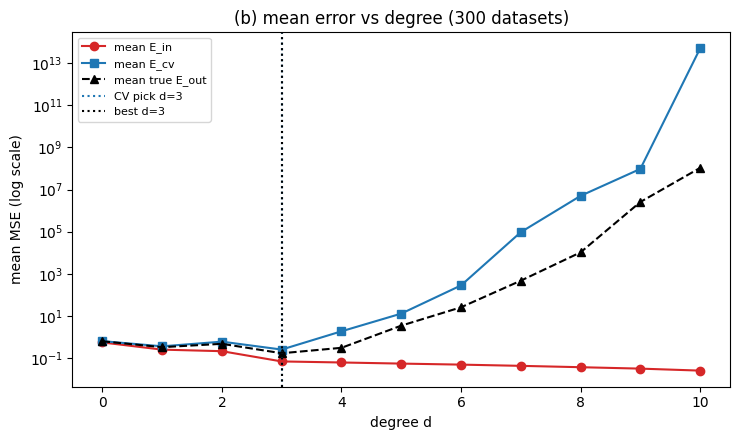

In [6]:
print("=== (b) ค่ากลาง error รายดีกรี (ทำซ้ำ %d ชุด, n=%d, sigma=%.2f) ==="
      % (M_DATASETS, N, SIGMA))
e_in, e_cv, e_out = mean_errors(N, SIGMA, K_FOLD, rng, MAXDEG, M_DATASETS)
d_train = int(np.argmin(e_in))                 # ดีกรีที่ training error ต่ำสุด
d_cv = int(np.argmin(e_cv))                    # ดีกรีที่ CV ต่ำสุด
d_out = int(np.argmin(e_out))                  # ดีกรีที่ E_out จริงต่ำสุด (คำตอบในอุดมคติ)

print(f"{'d':>3} | {'E_in':>9} {'E_cv':>9} {'E_out(จริง)':>11}")
print("-" * 40)
for d in range(MAXDEG + 1):
    print(f"{d:>3} | {e_in[d]:9.4f} {e_cv[d]:9.4f} {e_out[d]:11.4f}")
print(f"\nเลือกดีกรีด้วย training error -> d={d_train}  (มัก = D เพราะ E_in ลดลงตามดีกรีเสมอ = overfit)")
print(f"เลือกดีกรีด้วย CV            -> d={d_cv}   เทียบดีกรีดีที่สุดจริง (E_out ต่ำสุด) -> d={d_out}")
print(f"|E_cv - E_out| เฉลี่ยทุกดีกรี = {np.mean(np.abs(e_cv - e_out)):.4f}  (ยิ่งน้อย = CV ยิ่งแทน E_out ได้ดี)")

# --- วาดกราฟค่ากลาง 3 เส้นเทียบดีกรี ---
degs = np.arange(MAXDEG + 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(degs, e_in, "o-", color="tab:red", label="mean E_in")
ax.plot(degs, e_cv, "s-", color="tab:blue", label="mean E_cv")
ax.plot(degs, e_out, "^--", color="k", label="mean true E_out")
ax.axvline(d_cv, color="tab:blue", ls=":", lw=1.5, label=f"CV pick d={d_cv}")
ax.axvline(d_out, color="k", ls=":", lw=1.5, label=f"best d={d_out}")
ax.set_yscale("log")
ax.set_title(f"(b) mean error vs degree ({M_DATASETS} datasets)")
ax.set_xlabel("degree d"); ax.set_ylabel("mean MSE (log scale)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("mean_curves.png", dpi=120)
plt.show()

## (c) ปรับ $n$ และ $\sigma$

ดูผลต่อดีกรีที่ดีที่สุด (CV) และความรุนแรงของ overfitting  
*(เซลล์นี้ทำ Monte-Carlo หลายรอบ จึงใช้เวลารันนานกว่าหัวข้ออื่น)*

=== (c) ผลของ n และ sigma ต่อดีกรีที่ดีที่สุด และ overfitting ===
   n  sigma | best_d(CV)  overfit_gap
----------------------------------------
  10   0.00 |          7       0.0208
  20   0.00 |         10       0.0000
  40   0.00 |          9       0.0000
  80   0.00 |          9       0.0000
  10   0.20 |          1 1669955745281800.5000
  20   0.20 |          3    4698.5080
  40   0.20 |          3       1.8706
  80   0.20 |          5       0.0199
  10   0.50 |          1 4767482976213.2881
  20   0.50 |          3   41648.8499
  40   0.50 |          3      26.6472
  80   0.50 |          3       0.1367


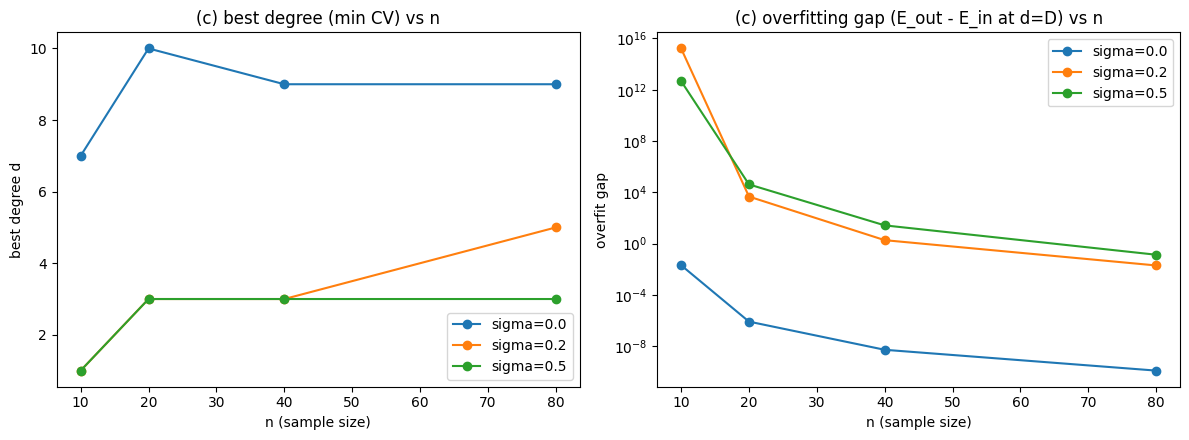


สรุป: n มากขึ้น -> รับดีกรีสูงได้/overfit ลดลง;  sigma มากขึ้น -> best degree ต่ำลง/overfit แรงขึ้น


In [7]:
print("=== (c) ผลของ n และ sigma ต่อดีกรีที่ดีที่สุด และ overfitting ===")
ns = [10, 20, 40, 80]                          # ค่า n ที่จะกวาด
sigmas = [0.0, 0.2, 0.5]                       # ค่า sigma ที่จะกวาด
# overfit gap = ช่องว่าง E_out - E_in ที่ดีกรีสูงสุด D (ยิ่งกว้าง = overfit ยิ่งแรง)
best_by_sig = {s: [] for s in sigmas}          # ดีกรีที่ CV ต่ำสุด แยกตาม sigma
gap_by_sig = {s: [] for s in sigmas}           # overfit gap แยกตาม sigma

print(f"{'n':>4} {'sigma':>6} | {'best_d(CV)':>10} {'overfit_gap':>12}")
print("-" * 40)
for sigma in sigmas:                           # วนแต่ละระดับ noise
    for n in ns:                               # วนแต่ละขนาดข้อมูล
        e_in, e_cv, e_out = mean_errors(n, sigma, K_FOLD, rng, MAXDEG, M_DATASETS)
        best = int(np.argmin(e_cv))            # ดีกรีที่ CV เฉลี่ยต่ำสุด
        gap = e_out[MAXDEG] - e_in[MAXDEG]     # ช่องว่างที่ดีกรีสูงสุด = ความรุนแรง overfit
        best_by_sig[sigma].append(best)
        gap_by_sig[sigma].append(gap)
        print(f"{n:>4} {sigma:>6.2f} | {best:>10} {gap:>12.4f}")

# --- วาด 2 subplot: best degree vs n และ overfit gap vs n (เส้นละ sigma) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for sigma in sigmas:
    ax[0].plot(ns, best_by_sig[sigma], "o-", label=f"sigma={sigma}")
    ax[1].plot(ns, gap_by_sig[sigma], "o-", label=f"sigma={sigma}")
ax[0].set_title("(c) best degree (min CV) vs n")
ax[0].set_xlabel("n (sample size)"); ax[0].set_ylabel("best degree d"); ax[0].legend()
ax[1].set_title("(c) overfitting gap (E_out - E_in at d=D) vs n")
ax[1].set_xlabel("n (sample size)"); ax[1].set_ylabel("overfit gap"); ax[1].legend()
ax[1].set_yscale("log")                        # gap เหวี่ยงกว้าง -> log อ่านง่ายกว่า
plt.tight_layout()
plt.savefig("n_sigma_effect.png", dpi=120)
plt.show()
print("\nสรุป: n มากขึ้น -> รับดีกรีสูงได้/overfit ลดลง;  sigma มากขึ้น -> best degree ต่ำลง/overfit แรงขึ้น")

## (d) ขนาดสัมประสิทธิ์สูงสุด $|w|$ เทียบดีกรี

เชื่อมโยงขนาดสัมประสิทธิ์กับการเกิด overfitting — $|w|$ ที่โตแบบระเบิดคือ "ลายเซ็น" ของ overfit

=== (d) ขนาดสัมประสิทธิ์สูงสุด |w| เทียบดีกรี (เฉลี่ย 300 ชุด, n=15, sigma=0.30) ===
  d |       max|w|      E_cv
------------------------------
  0 |        0.162    0.6421
  1 |        0.986    0.3528
  2 |        1.101    0.6557
  3 |        3.117    0.2970
  4 |        3.457    3.5945
  5 |        6.134  112.9729
  6 |       17.172 2298.1991
  7 |       65.279 225600.2772
  8 |      304.265 225228431.7397
  9 |     2517.523 103496887697.8499
 10 |    27416.375 151493802976641.2500
สังเกต: ดีกรีสูง -> max|w| โตแบบระเบิด (สัมประสิทธิ์บวก/ลบใหญ่หักล้างกันเพื่อลากผ่านทุกจุด)


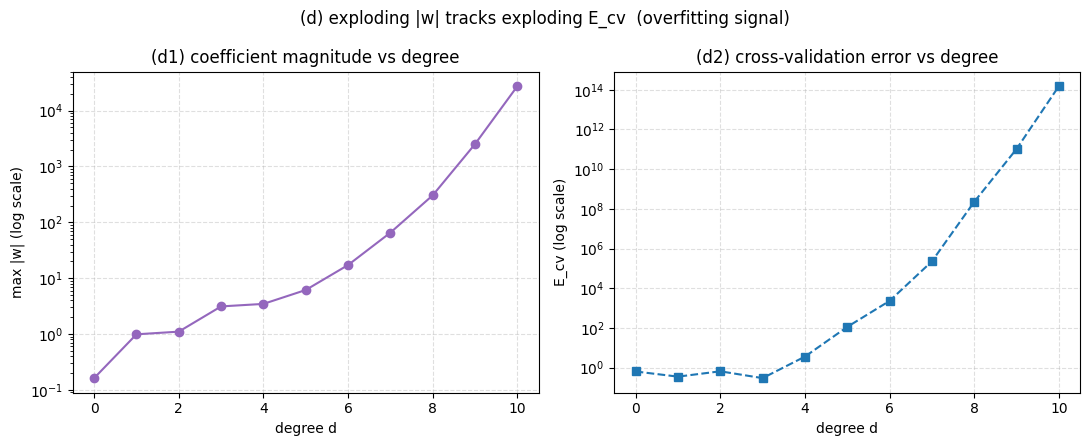

สรุป: |w| ที่พุ่งสูง = สัญญาณ overfitting; regularization คุมขนาด w เพื่อกันอาการนี้


In [8]:
print("=== (d) ขนาดสัมประสิทธิ์สูงสุด |w| เทียบดีกรี (เฉลี่ย %d ชุด, n=%d, sigma=%.2f) ==="
      % (M_DATASETS, N, SIGMA))
maxw = np.zeros(MAXDEG + 1)                     # ค่าเฉลี่ย max|w| รายดีกรี
e_cv = np.zeros(MAXDEG + 1)                     # ค่าเฉลี่ย E_cv รายดีกรี (ไว้วางคู่กัน)
for _ in range(M_DATASETS):                    # ทำซ้ำหลายชุดแล้วเฉลี่ย
    x, y = make_data(N, SIGMA, rng)
    for d in range(MAXDEG + 1):
        coef = fit_poly(x, y, d)               # ฟิตพหุนามดีกรี d
        maxw[d] += np.max(np.abs(coef))        # สัมประสิทธิ์ที่ใหญ่สุด (ขนาด)
        e_cv[d] += est_kfold(x, y, d, K_FOLD, rng)
maxw /= M_DATASETS; e_cv /= M_DATASETS

print(f"{'d':>3} | {'max|w|':>12} {'E_cv':>9}")
print("-" * 30)
for d in range(MAXDEG + 1):
    print(f"{d:>3} | {maxw[d]:12.3f} {e_cv[d]:9.4f}")
print("สังเกต: ดีกรีสูง -> max|w| โตแบบระเบิด (สัมประสิทธิ์บวก/ลบใหญ่หักล้างกันเพื่อลากผ่านทุกจุด)")

# --- วาดแยก 2 กราฟข้างกัน: (ซ้าย) max|w|  (ขวา) E_cv  ทั้งคู่แกน log ให้เห็นการไต่ขึ้น ---
degs = np.arange(MAXDEG + 1)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.5))

axL.plot(degs, maxw, "o-", color="tab:purple")   # ซ้าย: ขนาดสัมประสิทธิ์
axL.set_yscale("log")
axL.set_xlabel("degree d"); axL.set_ylabel("max |w| (log scale)")
axL.set_title("(d1) coefficient magnitude vs degree")
axL.grid(True, ls="--", alpha=0.4)

axR.plot(degs, e_cv, "s--", color="tab:blue")     # ขวา: cross-validation error
axR.set_yscale("log")
axR.set_xlabel("degree d"); axR.set_ylabel("E_cv (log scale)")
axR.set_title("(d2) cross-validation error vs degree")
axR.grid(True, ls="--", alpha=0.4)

fig.suptitle("(d) exploding |w| tracks exploding E_cv  (overfitting signal)")
plt.tight_layout()
plt.savefig("coef_growth.png", dpi=120)
plt.show()
print("สรุป: |w| ที่พุ่งสูง = สัญญาณ overfitting; regularization คุมขนาด w เพื่อกันอาการนี้")

## สรุปบทเรียน

- **training error ($E_{in}$)** ลดตามดีกรีเสมอ → ใช้เลือกดีกรีไม่ได้ (จะเลือกซับซ้อนเกิน = overfit)
- **cross-validation ($E_{cv}$)** เป็นรูปตัว U → จุดต่ำสุดคือดีกรีที่เหมาะ และเกาะติด $E_{out}$ จริงในย่านนั้น
- ยิ่งข้อมูลน้อย / noise มาก / ดีกรีสูง → overfitting ยิ่งรุนแรง (error และ $|w|$ ระเบิด)
- ขนาดสัมประสิทธิ์ $|w|$ ที่โตแบบระเบิด = ลายเซ็นของ overfitting และเป็นเหตุผลของการทำ **regularization**